# Hong-Ou-Mandel Example

This notebook reproduces the Hong–Ou–Mandel (HOM) coincidence surface
shown in the accompanying manuscript.

The focus here is on the **implementation side**:

- how non-orthogonal temporal modes are represented as mode labels,
- how the 50/50 beam splitter is implemented as a linear operator map,
- how the coincidence operator is constructed from the output modes, and
- how the coincidence probability is evaluated as an expectation value.

For the full derivation of the HOM state and the analytical expression
for the coincidence probability, please refer to the manuscript. This
notebook only illustrates how the operator-algebraic framework is used
to realize that construction in code.

In [1]:
from typing import Tuple
from symop_proto.envelopes.gaussian_envelope import GaussianEnvelope
from symop_proto.labels.path_label import PathLabel
from symop_proto.labels.polarization_label import PolarizationLabel
from symop_proto.labels.mode_label import ModeLabel
from symop_proto.core.operators import ModeOp
from symop_proto.state.polynomial_state import KetPolyState
from symop_proto.rewrites.linear_mode_unitary import LinearModeUnitary
from symop_proto.rewrites.functions.relabling import rename_path
from symop_proto.algebra.operator_polynomial import OpPoly, OpTerm
import numpy as np

## Mode construction
This function (`construct_modes`) builds the two input modes for the HOM experiment.  
Each mode label combines:

- a **temporal envelope** (Gaussian pulse) with given carrier frequency,
- a **polarization label**, and
- a **spatial path label** indicating the input arm of the beam splitter.

The parameter `delta_t` controls the temporal delay between the two pulses,
while `omega1` and `omega2` specify their angular frequencies (carrier detuning).
All mode descriptors are immutable objects, ensuring that mode labels refer to
fixed mathematical states throughout the simulation.

The output of `construct_modes` is therefore a pair of fully specified mode
labels, which are later used to build the two-photon input state.

In [2]:
def construct_modes(
    delta_t: float,
    omega1: float,
    omega2: float,
    *,
    sigma: float = 1.0,
) -> Tuple[ModeOp, ModeOp]:
    """
    Build two input modes for the HOM setup, with given carrier frequencies
    omega1, omega2 and relative delay delta_t.

    All units must be consistent (e.g. omega in rad/s, tau in seconds).
    """
    env1 = GaussianEnvelope(omega0=omega1, sigma=sigma, tau=0.0, phi0=0.0)
    env2 = GaussianEnvelope(omega0=omega2, sigma=sigma, tau=delta_t, phi0=0.0)

    m1 = ModeOp(env=env1, label=ModeLabel(PathLabel("A"), PolarizationLabel.H()))
    m2 = ModeOp(env=env2, label=ModeLabel(PathLabel("B"), PolarizationLabel.H()))
    return m1, m2

## State creation

The input two-photon state is constructed directly from the mode labels
produced in the previous step. Each mode label `m.create` is a creation
operator acting on that mode, and `KetPolyState.from_creators` builds the
normally ordered operator polynomial representing:


\begin{equation*}
|\psi\rangle = \hat{a}^\dagger(m_1)\,\hat{a}^\dagger(m_2)\,|0\rangle.
\end{equation*}


Because the framework uses immutable mode descriptors and symbolic
operator expressions, the resulting state is a direct executable
representation of the abstract two-photon state used in the manuscript.

In [3]:
def create_input_state(m1: ModeOp, m2: ModeOp) -> KetPolyState:
    psi_in = KetPolyState.from_creators([m1.create, m2.create])
    return psi_in

### Example state
The state can then easily be created and displayed:

In [4]:
m1, m2 = construct_modes(1, 0, 0)
psi = create_input_state(m1, m2)
display(psi)

(+1+0j)·m1† m2†·|0⟩

## Beam Splitter Logic

The framework represents devices as maps acting on mode operators.  
Since the high-level beam-splitter abstraction is not yet implemented, we
encode the HOM beam splitter explicitly in `apply_beam_splitter_full`.

This helper function realizes the 50/50 beam splitter in several
operator-level steps:

1. **Path relabelling** – the input state `psi_in` is rewritten so that
   the original paths (`A`, `B`) are mapped to internal paths (`BS1`, `BS2`).
2. **Mode discovery** – the function inspects `psi_internal.unique_modes`
   to obtain the actual internal modes present in the state.
3. **Unitary construction** – from these modes it builds four internal
   modes (two original and two “crossed” ones) and a block-diagonal 4x4
   unitary matrix implementing two identical 50/50 beam splitter blocks,
   one for each temporal/polarization “env”.
4. **Application** – the unitary is applied via `LinearModeUnitary` to
   produce the transformed state.
5. **Output relabelling** – finally, the internal paths are renamed to
   the physical output paths (`C`, `D`), and the corresponding output
   modes are returned for later use in the coincidence operator.

In this way, `apply_beam_splitter_full` is a direct code-level realization
of the linear device map described in the manuscript, acting on symbolic
mode operators rather than on numeric state vectors.


In [5]:
def apply_beam_splitter_full(
    psi_in: KetPolyState,
    m1: ModeOp,
    m2: ModeOp,
    *,
    in_path1: str = "A",
    in_path2: str = "B",
    internal_path1: str = "BS1",
    internal_path2: str = "BS2",
    out_path1: str = "C",
    out_path2: str = "D",
) -> Tuple[KetPolyState, Tuple[ModeOp, ModeOp, ModeOp, ModeOp]]:
    """
    One-shot HOM beam splitter:

      1) rename input paths in psi_in: in_path1, in_path2 -> internal_path1, internal_path2
      2) read the *actual* internal modes from psi_internal.unique_modes
      3) build a 4-mode 50/50 BS on those internal modes (block-diagonal in temporal mode)
      4) apply BS
      5) rename internal_path1/2 -> out_path1/2
      6) return psi_out and the four output modes (C_env1, D_env1, C_env2, D_env2)
    """

    # --- 1) rename input paths -> internal in the STATE ----------------------
    psi_internal = rename_path(psi_in, in_path1, internal_path1)
    psi_internal = rename_path(psi_internal, in_path2, internal_path2)

    # --- 2) get the actual internal modes from the state ---------------------
    # Expect exactly two: one on internal_path1 with env1, one on internal_path2 with env2
    internal_modes = psi_internal.unique_modes  # Tuple[ModeOp, ModeOp, ...]
    modes_by_path = {
        m.label.path.name: m for m in internal_modes if isinstance(m.label, ModeLabel)
    }

    try:
        mode_1_int = modes_by_path[internal_path1]  # env1, path BS1
        mode_2_int = modes_by_path[internal_path2]  # env2, path BS2
    except KeyError:
        raise RuntimeError(
            f"After renaming, state does not contain both internal paths "
            f"{internal_path1!r}, {internal_path2!r}; got {list(modes_by_path)}"
        )

    # env/pol taken from the modes actually in the state
    env1, pol1 = mode_1_int.env, mode_1_int.label.pol
    env2, pol2 = mode_2_int.env, mode_2_int.label.pol

    # --- 3) build 4 internal modes: 2 existing + 2 new cross-path modes ------
    # existing ones (these MUST be used so LinearModeUnitary recognizes them)
    A1_int = mode_1_int  # env1 on BS1
    B2_int = mode_2_int  # env2 on BS2

    # new ones (crossed paths)
    B1_int = ModeOp(
        env=env1, label=ModeLabel(PathLabel(internal_path2), pol1)
    )  # env1 on BS2
    A2_int = ModeOp(
        env=env2, label=ModeLabel(PathLabel(internal_path1), pol2)
    )  # env2 on BS1

    # 50/50 BS, block-diagonal in temporal mode
    c = s = 1 / np.sqrt(2)
    # basis ordering: (A1_int, B1_int, A2_int, B2_int)
    U = np.array(
        [
            [c, s, 0, 0],  # A1_out <= A1,B1   (env1 block)
            [-s, c, 0, 0],  # B1_out
            [0, 0, c, s],  # A2_out <= A2,B2   (env2 block)
            [0, 0, -s, c],  # B2_out
        ],
        dtype=complex,
    )

    BS_internal = LinearModeUnitary((A1_int, B1_int, A2_int, B2_int), U)

    # --- 4) apply BS to the internal state -----------------------------------
    psi_after_bs_int = BS_internal.on_state(psi_internal)

    # --- 5) rename internal paths -> output paths in the STATE ---------------
    psi_out = rename_path(psi_after_bs_int, internal_path1, out_path1)
    psi_out = rename_path(psi_out, internal_path2, out_path2)

    # --- 6) build output modes for coincidence operators ---------------------
    C_env1 = ModeOp(env=env1, label=ModeLabel(PathLabel(out_path1), pol1))
    D_env1 = ModeOp(env=env1, label=ModeLabel(PathLabel(out_path2), pol1))
    C_env2 = ModeOp(env=env2, label=ModeLabel(PathLabel(out_path1), pol2))
    D_env2 = ModeOp(env=env2, label=ModeLabel(PathLabel(out_path2), pol2))

    return psi_out, (C_env1, D_env1, C_env2, D_env2)

## Mixed example state

We can now mix the example state from above:

In [6]:
psi_bs, (C1, D1, C2, D2) = apply_beam_splitter_full(
    psi,
    m1,
    m2,
    in_path1="A",
    in_path2="B",
    internal_path1="BS1",
    internal_path2="BS2",
    out_path1="C",
    out_path2="D",
)
display(psi_bs)

(+0.5+0j)·m1† m2† + (+0.5+0j)·m1† m3† + (-0.5+0j)·m2† m4† + (-0.5+0j)·m3† m4†·|0⟩

## Coincidence operator

The coincidence observable is constructed from the number operators on
the two output paths of the beam splitter. Each number operator is built
as a sum over the mode-local terms

\begin{equation*}
\hat{n}_m = \hat{a}^\dagger(m)\hat{a}(m),
\end{equation*}

for all modes belonging to a given path.  
`number_operator_for_modes` implements exactly this by generating one
term per mode label and collecting them into an operator polynomial.

The coincidence operator is then the product of the number operators on
the two output ports:

\begin{equation*}
\hat{C} = \hat{n}_{C}\hat{n}_{D},
\end{equation*}

matching the definition used in the manuscript for evaluating the HOM
coincidence probability. Because the framework uses symbolic operator
polynomials, multiplication automatically triggers the normal-ordering
and contraction rules when the expectation value is evaluated later.

In [ ]:
def number_operator_for_modes(*modes: ModeOp) -> OpPoly:
    terms = []
    for m in modes:
        terms.append(OpTerm(coeff=1.0, ops=(m.create, m.ann)))
    return OpPoly(tuple(terms))


def coincidence_operator(C1: ModeOp, D1: ModeOp, C2: ModeOp, D2: ModeOp) -> OpPoly:
    N_C = number_operator_for_modes(C1, C2)
    N_D = number_operator_for_modes(D1, D2)
    return N_C * N_D

## Compute the coincidence (single shot)

This helper wraps the full HOM pipeline into a single function that, for
given parameters $\Delta t$, $\omega_1$, $\omega_2$ and $\sigma$,
returns the coincidence probability for that configuration.

The steps are:

1. **Build modes and input state** – construct the two mode labels with
   the requested delay and detuning, then form the two-photon input
   state.
2. **Apply the beam splitter** – use `apply_beam_splitter_full` to obtain
   the output state and the four output mode labels on paths \(C\) and \(D\).
3. **Construct the coincidence operator** – build the product of number
   operators on the two output ports.
4. **Evaluate the expectation value** – call `psi_out.expect(C_op)`, which
   internally carries out normal ordering and contractions according to
   the operator algebra, yielding the coincidence probability
   $P_\text{coinc}$ for this parameter point.


In [8]:
def hom_coincidence_probability(
    delta_t: float,
    omega1: float,
    omega2: float,
    *,
    sigma: float = 1.0,
) -> float:
    # 1) build modes + input state
    m1, m2 = construct_modes(delta_t, omega1, omega2, sigma=sigma)
    psi_in = create_input_state(m1, m2)

    # 2) beam splitter + output modes on C/D
    psi_out, (C1, D1, C2, D2) = apply_beam_splitter_full(
        psi_in,
        m1,
        m2,
        in_path1="A",
        in_path2="B",
        internal_path1="BS1",
        internal_path2="BS2",
        out_path1="C",
        out_path2="D",
    )

    # 3) coincidence operator
    C_op = coincidence_operator(C1, D1, C2, D2)

    # 4) expectation value
    P = psi_out.expect(C_op)  # complex, but imag ~ 0
    return float(P.real)

## Parameter sweep for the HOM surface

To reproduce the coincidence surface shown in the manuscript, we evaluate
the coincidence probability on a two-dimensional grid of time delays and
spectral detunings.

The time delay range corresponds to the experimental window used in the
HOM measurement (roughly $\pm50$ micrometers converted to time by dividing
by the speed of light). The spectral detuning range is centered at zero
and spans a symmetric interval around the carrier frequency.

The temporal width of the Gaussian pulse is chosen such that the full
width at half maximum (FWHM) matches the experimental value,
\begin{equation*}
\text{FWHM} = 2\sqrt{2\ln 2}\,\sigma_t,
\end{equation*}
so that
\begin{equation*}
\sigma_t = \frac{\text{FWHM}}{2.355}.
\end{equation*}

For each pair $(\Delta t, \Delta \omega)$, the procedure is:

1. construct the two input modes with the specified delay and detuning,
2. build the corresponding two-photon input state,
3. apply the 50/50 beam splitter transformation,
4. evaluate the coincidence operator on the output state.

The resulting values are stored in the 2D array `P`, where index `i`
corresponds to detuning and index `j` corresponds to delay.

In [ ]:
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# delay range
t_min, t_max = -1.7e-13, 1.7e-13
N_t = 101
delta_ts = np.linspace(t_min, t_max, N_t)

omega0 = 0
# detuning range
domega_min, domega_max = -1e14, 1e14
N_w = 101
delta_omegas = np.linspace(domega_min, domega_max, N_w)


delta_tau_FWHM = 3.9e-14  # target from experiment
sigma_t = delta_tau_FWHM / 2.355

sigma = 1.7e-14  # seconds

# Storage array
P = np.empty((N_w, N_t), dtype=float)

for i, domega in enumerate(tqdm(delta_omegas, desc="omega sweep")):
    omega1 = omega0
    omega2 = omega0 + domega
    for j, dt in enumerate(tqdm(delta_ts, desc="delay sweep", leave=False)):
        P[i, j] = hom_coincidence_probability(dt, omega1, omega2, sigma=sigma)

## Plotting
We are ready to plot the coincidence dependence on the temporal and frequential missmatch between the incomming photons.

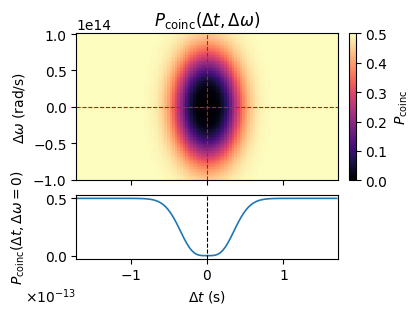

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import ScalarFormatter, NullFormatter

# assume delta_ts, delta_omegas, P already computed
idx_w0 = np.argmin(np.abs(delta_omegas))
P_vs_t = P[idx_w0, :]
T, DW = np.meshgrid(delta_ts, delta_omegas)

fig = plt.figure(figsize=(5, 3), constrained_layout=True)
gs = GridSpec(2, 1, height_ratios=[2.8, 1.2], figure=fig)

ax_main = fig.add_subplot(gs[0, 0])
ax_t = fig.add_subplot(gs[1, 0], sharex=ax_main)

# --- main colormap ---
pcm = ax_main.pcolormesh(T, DW, P, shading="auto", cmap="magma")
ax_main.set_ylabel(r"$\Delta \omega$ (rad/s)")
ax_main.set_title(r"$P_\mathrm{coinc}(\Delta t,\Delta \omega)$")

ax_main.axhline(0.0, color="r", ls="--", lw=0.8)
ax_main.axvline(0.0, color="r", ls="--", lw=0.8)

ax_main.tick_params(axis="x", labelbottom=False)
ax_main.xaxis.set_major_formatter(NullFormatter())
ax_main.xaxis.offsetText.set_visible(False)

cbar = fig.colorbar(pcm, ax=ax_main, fraction=0.047, pad=0.04)
cbar.set_label(r"$P_\mathrm{coinc}$")

ax_t.plot(delta_ts, P_vs_t, "-", lw=1.2)
ax_t.axvline(0.0, color="k", ls="--", lw=0.8)

ax_t.set_xlabel(r"$\Delta t$ (s)")
ax_t.set_ylabel(r"$P_\mathrm{coinc}(\Delta t, \Delta \omega=0)$")


fmt = ScalarFormatter(useMathText=True)
fmt.set_powerlimits((-2, 2))
ax_t.xaxis.set_major_formatter(fmt)

offset = ax_t.xaxis.get_offset_text()
offset.set_x(0.0)
offset.set_y(-0.12)


fig.align_xlabels([ax_main, ax_t])
fig.align_ylabels([ax_main, ax_t])
fig.set_constrained_layout_pads(w_pad=0.5, h_pad=0.02)

plt.show()
fig.savefig("hom_coincidence.pdf", dpi=600, bbox_inches="tight")